# ¹⁸O gadget on D-Wave with a **global** transverse field and **tuned chain couplings**

**Question.** D-Wave only gives us one global, uniform transverse field $\Omega$ (the annealing
schedule $A(s)$). There is no per-qubit field, so we can't program the non-uniform drive $d_a$
that the rank-1 gadget needs. Can the **ferromagnetic coupling of each chain, $J_{F,a}$**, do two
jobs at once?

1. **Constraint.** It keeps chain $a$ aligned, so the chain acts as one logical qubit.
2. **Tuning.** It sets the effective logical drive $d_a$ produced by the global $\Omega$.

**Idea in one line.** A chain of $k$ qubits flips as a whole only at order $k$ in $\Omega$, so its
effective transverse field is $t_a \simeq \Omega^{k}/J_{F,a}^{\,k-1}$. With a fixed $\Omega$ you pick
$J_{F,a}$ to get the $t_a$ you want.

**Scope.** ¹⁸O only: $N=1$ neutron pair on the $D=6$ sd levels, particle-conservation (one-hot)
encoding, minor-embedded on Pegasus.

**Contents**
1. Target problem and rank-1 drive fit ($d_a$, $c_{ab}$)
2. Theory: the chain as a tunable transverse field (exact result for $k=2$), and why the signs of $d_a$ cost nothing (gauge)
3. The embedding: every chain padded to $k\ge 2$
4. The physical Hamiltonian: global $\Omega$ plus per-chain $J_{F,a}$
5. One working point: fidelity and $\psi(a)$ bar plot
6. Scan on the grid $(\gamma,\ J_F/\gamma)$ and comparison with the unembedded gadget
7. What the hardware has to provide

In [1]:
# --- setup -----------------------------------------------------------------
import os, sys, time, warnings

warnings.filterwarnings("ignore")  # numba / NSMFermions cast warnings

# the notebook lives in the repo root; make `src` importable from anywhere
ROOT = os.path.abspath("")
if not os.path.isdir(os.path.join(ROOT, "src")):
    raise RuntimeError("run this notebook from the repository root")
sys.path.insert(0, ROOT)

import numpy as np
import scipy.linalg as sla
from scipy.optimize import brentq
import networkx as nx
import dwave_networkx as dnx
import matplotlib.pyplot as plt

from src.gadget import (
    QuasiparticleProblem,
    ParticleConservationEncoding,
    MinorEmbeddedEncoding,
    GadgetHamiltonian,
    GadgetParameters,
    fit_drive,
    find_minor_embedding,
    alpha_from_c,
)
from src.gadget.embedding import from_minorminer

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Target problem: ¹⁸O

$$H_{\rm log}=\sum_a \varepsilon_a N_a+\sum_{a<b} g_{ab}\,(a^\dagger_a a_b+{\rm h.c.}),\qquad N=1 .$$

The drive fit (`fit_drive`) gives the rank-1 amplitudes $d_a$ and the per-pair constraint
corrections $c_{ab}$, such that $g_{ab}\simeq-\alpha_{ab}\,d_a d_b/\gamma$ with
$\alpha_{ab}=\tfrac12[1+1/(1+c_{ab})]$.

In [2]:
ONEBODY = os.path.join(ROOT, "data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
problem = QuasiparticleProblem.from_npz(ONEBODY, n_levels=6, n_particles=1, label="O18")
E_exact, psi_exact = problem.exact_groundstate()
D = problem.n_levels
print(f"E0(O18) = {E_exact:.6f} MeV")
print("psi_exact(a) =", np.round(psi_exact, 4))

# CAP: the notebooks' |c_ab| regularisation (4.0). cap=None gives exact c but can hit c<-1
# (see claude/gadget-fidelity-diagnosis-O18.md): it sets the O18 fidelity floor.
CAP = 4.0
drive = fit_drive(problem.g1, n_restarts=50, cap=CAP, seed=42)
d = drive.d
g_real = -alpha_from_c(drive.c_matrix) * np.outer(d, d)
np.fill_diagonal(g_real, 0)
print("d_a          =", np.round(d, 4))
print(
    "max |g_real - g| =",
    f"{np.abs(g_real - problem.g1).max():.2e}  (rank-1 + capped c)",
)

E0(O18) = -11.931788 MeV
psi_exact(a) = [ 0.5086 -0.5086  0.5086  0.4181  0.1566 -0.1566]
d_a          = [ 0.9051 -1.0254  0.9615  0.7942  1.1051 -1.135 ]
max |g_real - g| = 5.43e-02  (rank-1 + capped c)


## 2. Theory: the chain as a tunable transverse field

### 2.1 Chain of length $k=2$: exact result
One logical qubit is two physical qubits:
$$H_{\rm chain}=-J\,Z_1Z_2+J+\Omega\,(X_1+X_2).$$

Take the basis $\{|00\rangle,|11\rangle\}$ (the logical doublet, energy $0$) and
$|S\rangle=(|01\rangle+|10\rangle)/\sqrt2$ (a domain wall, energy $2J$).
- The odd combination $(|00\rangle-|11\rangle)/\sqrt2$ is decoupled and stays at $0$.
- The even combination couples to $|S\rangle$ with matrix element $2\Omega$, so its energy is $J-\sqrt{J^2+4\Omega^2}$.

So the doublet is split by $2t$, with
$$\boxed{\,t=\tfrac12\left(\sqrt{J^2+4\Omega^2}-J\right)\simeq\frac{\Omega^2}{J}\,}
\quad\Longleftrightarrow\quad
\boxed{\,J=\frac{\Omega^2-t^2}{t}\,}\;\;\text{(exact inversion)}$$

The doublet also shifts rigidly by $-t$. That is a constant per chain, which we subtract from the energy.
The effective logical term is $-t\,X_L$: the ground state is the even combination.

### 2.2 General $k$
At order $k$ on a tree, $t=\Omega^k/J^{k-1}$ (one factor $1/J$ per bond). The sign is $(-1)^{k-1}$
because there are $k-1$ negative energy denominators (see `src/gadget/embedding.py`). Below, the
code calibrates **any** $k$ exactly by diagonalising the isolated chain and root-finding $J$.

### 2.3 Target
In the one-hot encoding the logical drive is $(d_a/\sqrt2)X_a$, so
$$t_a=\frac{|d_a|}{\sqrt2},\qquad J_{F,a}=J(t_a;\Omega,k_a).$$

Consequences:
- **Larger $|d_a|$ gives a smaller $J_{F,a}$.**
- **A chain of length 1 can't be tuned:** its drive is just $\Omega$. So every chain is padded to $k\ge2$.

### 2.4 Signs are free (gauge)
The global $\Omega>0$ gives every chain the sign $(-1)^{k_a-1}$, but the fit wants $\mathrm{sign}(d_a)$.
The longitudinal Hamiltonian is diagonal, so it commutes with $U=\prod_{a\in S}Z_{q_a}$ (one physical
qubit $q_a$ per flipped chain). $U$ flips the sign of the logical $X_a$ and maps the ground state
$\psi(a)\to\sigma_a\psi(a)$, with
$$\sigma_a=\mathrm{sign}(d_a)\,(-1)^{k_a-1}.$$
Spectrum and probabilities are identical. The amplitudes are compared after multiplying by
$\sigma_a$ (known a priori, no fitting). This works for any $N$ because $U$ is diagonal
(for $N>1$, multiply the $\sigma$'s of the occupied levels).

### 2.5 How large must $J_{F,a}$ be?
Each chain qubit also carries constraint couplers of order $\gamma$ to the other chains. Its
domain-wall cost is then $2J\pm O(\gamma)$, which depends on the configuration. This leaves a
spurious logical field $\sim\Omega^2\gamma/J^2\sim|d|\gamma/J$. For that to be small compared with
the logical scale $d^2/\gamma$ we need
$$J_{F}\gg\gamma^2/|d| .$$
So on the grid $(\gamma,\,J_F/\gamma)$ we expect a **diagonal** boundary: at fixed $J_F/\gamma$,
increasing $\gamma$ improves the gadget ($\sim\gamma^{-2}$ leakage) but softens the chains relative
to $\gamma^2$. The best $\gamma$ is therefore finite.

In [3]:
# --- isolated-chain calibration ------------------------------------------------
def chain_hamiltonian(k, J, Omega):
    # H = sum_bonds (-J Z Z + J) + Omega sum X  on an open chain of k qubits (dense)
    dim = 1 << k
    idx = np.arange(dim)
    spins = [1 - 2 * ((idx >> (k - 1 - q)) & 1) for q in range(k)]  # Z eigenvalues
    diag = np.zeros(dim)
    for q in range(k - 1):
        diag += -J * spins[q] * spins[q + 1] + J
    H = np.diag(diag)
    for q in range(k):
        H[idx, idx ^ (1 << (k - 1 - q))] += Omega
    return H


def chain_doublet(k, J, Omega):
    # (t, centre): half-splitting and centre of the two lowest levels
    w = np.linalg.eigvalsh(chain_hamiltonian(k, J, Omega))[:2]
    return 0.5 * (w[1] - w[0]), 0.5 * (w[0] + w[1])


def calibrate_J(t, k, Omega, method="exact"):
    # J such that the isolated chain realises the logical field t.
    # method = "exact": k=2 closed form, k>2 root finding on the exact doublet
    #          "pert" : leading order  J = (Omega^k / t)^(1/(k-1))
    # Returns (J, centre) - centre is the rigid shift of the doublet (energy offset).
    if k < 2:
        raise ValueError("a chain of length 1 cannot be tuned: pad it")
    J_pert = (Omega**k / t) ** (1.0 / (k - 1))
    if method == "pert":
        J = J_pert
    elif k == 2:
        J = (Omega**2 - t**2) / t
    else:
        J = brentq(
            lambda J: chain_doublet(k, J, Omega)[0] - t,
            0.2 * J_pert,
            5 * J_pert,
            xtol=1e-12 * J_pert,
        )
    return J, chain_doublet(k, J, Omega)[1]


# checks: closed form vs exact diagonalisation, and perturbative vs exact J
Omega_test, t_test = 5.0, 0.3
for k in (2, 3, 4):
    J, _ = calibrate_J(t_test, k, Omega_test)
    Jp, _ = calibrate_J(t_test, k, Omega_test, "pert")
    print(
        f"k={k}: J_exact={J:10.4f}  J_pert={Jp:10.4f}  "
        f"t(J_exact)={chain_doublet(k, J, Omega_test)[0]:.6f}  target {t_test}"
    )

k=2: J_exact=   83.0333  J_pert=   83.3333  t(J_exact)=0.300000  target 0.3
k=3: J_exact=   19.7549  J_pert=   20.4124  t(J_exact)=0.300000  target 0.3
k=4: J_exact=   11.9962  J_pert=   12.7718  t(J_exact)=0.300000  target 0.3


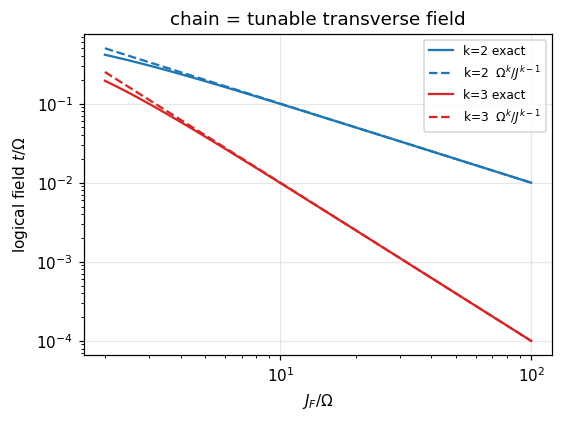

In [4]:
# Figure: logical field t vs J/Omega for k = 2, 3 (exact vs perturbative)
fig, ax = plt.subplots(figsize=(5.5, 3.8))
Om = 1.0
r = np.logspace(0.3, 2, 40)  # J / Omega
for k, col in ((2, "C0"), (3, "C3")):
    t_ex = [chain_doublet(k, x * Om, Om)[0] for x in r]
    ax.loglog(r, t_ex, "-", color=col, label=f"k={k} exact")
    ax.loglog(
        r,
        Om**k / (r * Om) ** (k - 1),
        "--",
        color=col,
        label=f"k={k}  $\\Omega^k/J^{{k-1}}$",
    )
ax.set_xlabel(r"$J_F/\Omega$")
ax.set_ylabel(r"logical field $t/\Omega$")
ax.set_title("chain = tunable transverse field")
ax.legend(fontsize=8)
plt.show()

## 3. Embedding: $K_6$ on Pegasus with every chain of length $\ge 2$

- `minorminer` usually returns some chains of length 1.
- We **pad** each length-1 chain with a free hardware neighbour. This costs one extra qubit per chain and makes every logical qubit tunable.
- The inter-chain couplers are then recomputed (`from_minorminer`).

In [5]:
hardware = dnx.pegasus_graph(8)
emb_raw = find_minor_embedding(D, hardware=hardware, tries=10, seed=1)
print("minorminer chains :", emb_raw.chain_lengths())

# back to hardware labels, pad length-1 chains with an unused neighbour
chains_hw = {
    a: [emb_raw.hardware_of[q] for q in ch] for a, ch in emb_raw.chains.items()
}
used = {q for ch in chains_hw.values() for q in ch}
for a, ch in chains_hw.items():
    if len(ch) == 1:
        free = next(v for v in hardware.neighbors(ch[0]) if v not in used)
        ch.append(free)
        used.add(free)

emb = from_minorminer(chains_hw, hardware, nx.complete_graph(D))
assert emb.check(verbose=False), "a logical pair lost its coupler"
k_len = np.array([len(emb.chains[a]) for a in range(D)])
print(
    "padded chains     :", emb.chain_lengths(), f"-> {emb.n_physical} physical qubits"
)
encoding = MinorEmbeddedEncoding(ParticleConservationEncoding(problem), emb)

minorminer chains : {0: 1, 1: 1, 2: 2, 3: 1, 4: 2, 5: 1}
padded chains     : {0: 2, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2} -> 12 physical qubits


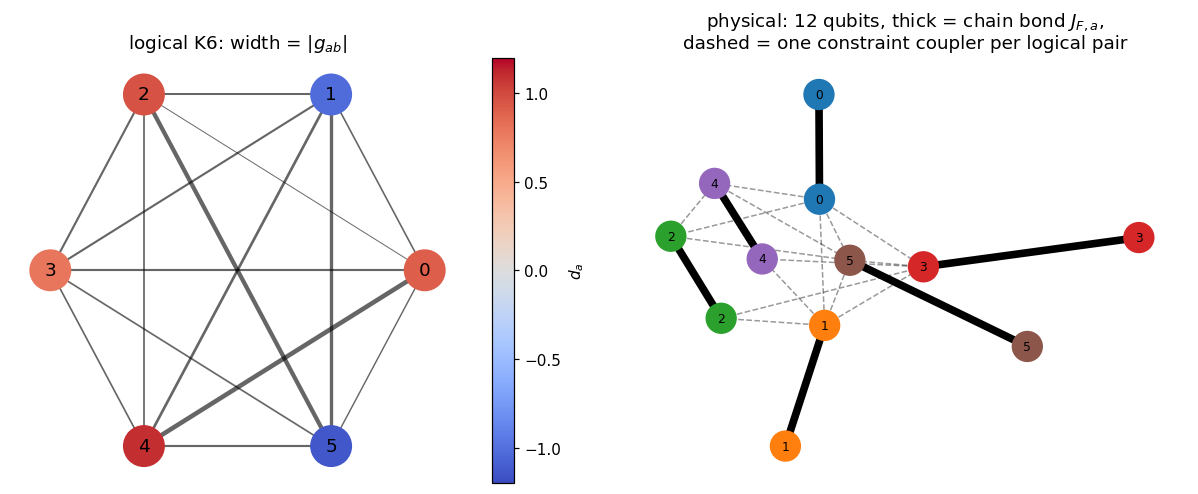

In [6]:
# Figure: logical K6 (node colour = d_a)  and  physical embedding (colour = chain)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

G_log = nx.complete_graph(D)
pos = nx.circular_layout(G_log)
w = np.array([abs(problem.g1[u, v]) for u, v in G_log.edges()])
nx.draw_networkx_edges(G_log, pos, ax=axes[0], width=3 * w / w.max(), alpha=0.6)
nodes = nx.draw_networkx_nodes(
    G_log,
    pos,
    ax=axes[0],
    node_color=d,
    cmap="coolwarm",
    vmin=-1.2,
    vmax=1.2,
    node_size=700,
)
nx.draw_networkx_labels(G_log, pos, ax=axes[0], labels={a: f"{a}" for a in range(D)})
plt.colorbar(nodes, ax=axes[0], label="$d_a$")
axes[0].set_title("logical K6: width = $|g_{ab}|$")
axes[0].axis("off")

G_phys = nx.Graph()
G_phys.add_nodes_from(range(emb.n_physical))
p2l = emb.phys_to_logical()
G_phys.add_edges_from(emb.intra_edges, kind="chain")
G_phys.add_edges_from(emb.couplers().values(), kind="coupler")
pos_p = nx.spring_layout(G_phys, seed=3, k=0.9)
chain_e = [e for e in G_phys.edges() if G_phys.edges[e]["kind"] == "chain"]
coup_e = [e for e in G_phys.edges() if G_phys.edges[e]["kind"] == "coupler"]
nx.draw_networkx_edges(
    G_phys, pos_p, edgelist=coup_e, ax=axes[1], style="--", alpha=0.4
)
nx.draw_networkx_edges(
    G_phys, pos_p, edgelist=chain_e, ax=axes[1], width=5, edge_color="k"
)
nx.draw_networkx_nodes(
    G_phys,
    pos_p,
    ax=axes[1],
    node_color=[p2l[q] for q in G_phys],
    cmap="tab10",
    vmin=0,
    vmax=9,
    node_size=380,
)
nx.draw_networkx_labels(
    G_phys, pos_p, ax=axes[1], labels={q: p2l[q] for q in G_phys}, font_size=8
)
axes[1].set_title(
    f"physical: {emb.n_physical} qubits, thick = chain bond $J_{{F,a}}$,\n"
    "dashed = one constraint coupler per logical pair"
)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 4. Parametrisation: one scale $J_F$, ratios $r_a$, global $\Omega$

$$J_{F,a}=J_F\,r_a,\qquad \Omega^{k}=J_F^{\,k-1}\ \ (\Omega=\sqrt{J_F}\ \text{for}\ k=2)$$

At leading order the logical field of chain $a$ is
$$t_a=\frac{\Omega^k}{J_{F,a}^{k-1}}=\frac{J_F^{k-1}}{J_F^{k-1}r_a^{k-1}}=\frac{1}{r_a^{k-1}}
\quad\xrightarrow{k=2}\quad t_a=\frac1{r_a}.$$

**Result:** the scale $J_F$ drops out. The drive is set **only by the dimensionless ratios**
$$r_a=t_a^{-1/(k-1)},\qquad t_a=\frac{|d_a|}{\sqrt2}\quad(k=2:\ r_a=\sqrt2/|d_a|).$$

- `R_MODE = "pert"`: exactly this, $r_a=1/t_a$. It has an $O(1/J_F)$ error.
- `R_MODE = "exact"`: the exact $k=2$ inversion $J_{F,a}=(\Omega^2-t_a^2)/t_a$ with $\Omega^2=J_F$,
  i.e. $r_a=(1-t_a^2/J_F)/t_a$.
- **Free parameters:** only $\gamma$ and $J_F$. We scan the grid $(\gamma,\ J_F/\gamma)$.

**Physical Hamiltonian**
$$H_{\rm phys}=\underbrace{\sum_{(a,b)}w_{ab}\,N_{u_{ab}}N_{v_{ab}}+\sum_a\frac{h_a}{k_a}\sum_{q\in a}N_q}_{\text{one-hot gadget terms}}
+\sum_a J_F r_a\sum_{(q,q')\in a}(1-Z_qZ_{q'})+\sqrt{J_F}\sum_q X_q$$

- $w_{ab}=(2+c_{ab})\gamma$ and $h_a=(\varepsilon_a+\theta_a)/\gamma+\gamma(1-2N)$ come from the
  unembedded builder, with the exact self-energy $\theta_a$.
- There are 12 qubits, so exact dense diagonalisation.

In [7]:
R_MODE = "exact"  # "pert": r_a = 1/t_a   |  "exact": k=2 inversion
t_target = np.abs(d) / np.sqrt(2)  # logical field each chain must produce


def ratios(J_F, mode=R_MODE):
    # r_a such that J_F,a = J_F r_a and Omega^k = J_F^(k-1) give t_a
    r = np.empty(D)
    for a in range(D):
        k, t = k_len[a], t_target[a]
        if mode == "pert" or k != 2:
            r[a] = t ** (-1.0 / (k - 1))
        else:
            r[a] = (1.0 - t**2 / J_F) / t
    return r


def global_field(J_F):
    # Omega^k = J_F^(k-1); all chains must share it -> requires a single chain length
    ks = set(k_len.tolist())
    if len(ks) != 1:
        raise ValueError(
            f"mixed chain lengths {ks}: Omega^k = J_F^(k-1) is not one number"
        )
    k = ks.pop()
    return J_F ** ((k - 1.0) / k)


print("r_a (pert)            =", np.round(ratios(1e6, "pert"), 4))
print("r_a (exact, J_F=1e2)  =", np.round(ratios(1e2, "exact"), 4))
print(
    "spread max r / min r  =",
    round(ratios(1e6).max() / ratios(1e6).min(), 3),
    "= max|d| / min|d|",
)

r_a (pert)            = [1.5624 1.3792 1.4708 1.7807 1.2797 1.246 ]
r_a (exact, J_F=1e2)  = [1.556  1.372  1.464  1.7751 1.2719 1.238 ]
spread max r / min r  = 1.429 = max|d| / min|d|


In [8]:
def base_terms(gamma):
    # (zz, z, const) of the UNEMBEDDED one-hot gadget, from the repo builder
    H0 = GadgetHamiltonian(
        problem,
        ParticleConservationEncoding(problem),
        drive,
        GadgetParameters(gamma=gamma, self_energy="exact"),
    )
    return H0._base_terms(H0.encoding)


def physical_hamiltonian(gamma, Omega, J_chain):
    # dense H_phys (2^n x 2^n); J_chain[a] = ferromagnetic bond of chain a
    zz, z, const = base_terms(gamma)
    n = emb.n_physical
    idx = np.arange(1 << n)
    N = [((idx >> (n - 1 - q)) & 1).astype(float) for q in range(n)]  # qutip MSB order
    diag = np.full(1 << n, float(const))
    couplers = emb.couplers()  # one representative coupler per pair
    for (a, b), w in zz.items():
        u, v = couplers[(a, b)]
        diag += w * N[u] * N[v]
    for a, h in z.items():
        for q in emb.chains[a]:
            diag += h / len(emb.chains[a]) * N[q]
    for u, v in emb.intra_edges:  # chain bonds J_F r_a, re-centred
        J = J_chain[p2l[u]]
        diag += -J * (1 - 2 * N[u]) * (1 - 2 * N[v]) + J
    H = np.diag(diag)
    for q in range(n):  # GLOBAL transverse field
        H[idx, idx ^ (1 << (n - 1 - q))] += Omega
    return H


# gauge signs sigma_a = sign(d_a) (-1)^(k_a - 1)   (section 2.4)
sigma = np.sign(d) * (-1.0) ** (k_len - 1)


def run_point(gamma, J_F, mode=R_MODE):
    Omega = global_field(J_F)
    r = ratios(J_F, mode)
    J_chain = {a: J_F * r[a] for a in range(D)}
    # rigid shift of every chain doublet (constant, removed from the energy)
    offset = sum(chain_doublet(k_len[a], J_chain[a], Omega)[1] for a in range(D))
    H = physical_hamiltonian(gamma, Omega, J_chain)
    w, v = sla.eigh(H, subset_by_index=[0, 1])
    amps = sigma * encoding.project(v[:, 0]).real  # gauge-fixed logical amplitudes
    norm2 = float(amps @ amps)
    F = float((amps @ psi_exact) ** 2)
    energy = (w[0] - offset) * gamma  # back to MeV
    return dict(
        gamma=gamma,
        J_F=J_F,
        Omega=Omega,
        r=r,
        infidelity=1 - F,
        infidelity_code=1 - F / norm2,
        leakage=1 - norm2,
        energy=energy,
        rel_energy_error=abs(energy - E_exact) / abs(E_exact),
        gap=(w[1] - w[0]) * gamma,
        amps=amps / np.sqrt(norm2),
    )


def run_unembedded(gamma):
    H = GadgetHamiltonian(
        problem,
        ParticleConservationEncoding(problem),
        drive,
        GadgetParameters(gamma=gamma, self_energy="exact"),
    )
    r = H.check(verbose=False)
    return 1 - r["fidelity"], r["relative_energy_error"]

## 5. One working point: $\gamma=100$, $J_F=10^4\gamma$

In [9]:
t0 = time.time()
res = run_point(gamma=100.0, J_F=1e4 * 100.0)
inf_u, dE_u = run_unembedded(100.0)
print(f"J_F = {res['J_F']:.3g},  Omega = sqrt(J_F) = {res['Omega']:.2f}")
print("r_a =", np.round(res["r"], 4))
print(f"1-F (with leakage)      : {res['infidelity']:.3e}   unembedded: {inf_u:.3e}")
print(f"1-F (in code space)     : {res['infidelity_code']:.3e}")
print(f"leakage                 : {res['leakage']:.3e}")
print(
    f"|dE|/|E|                : {res['rel_energy_error']:.3e}   unembedded: {dE_u:.3e}"
)
print(f"physical gap (MeV)      : {res['gap']:.3f}   ({time.time() - t0:.1f}s)")

J_F = 1e+06,  Omega = sqrt(J_F) = 1000.00
r_a = [1.5624 1.3792 1.4708 1.7807 1.2797 1.246 ]
1-F (with leakage)      : 9.050e-04   unembedded: 9.283e-04
1-F (in code space)     : 1.343e-05
leakage                 : 8.916e-04
|dE|/|E|                : 7.142e-05   unembedded: 1.728e-03
physical gap (MeV)      : 3.052   (3.7s)


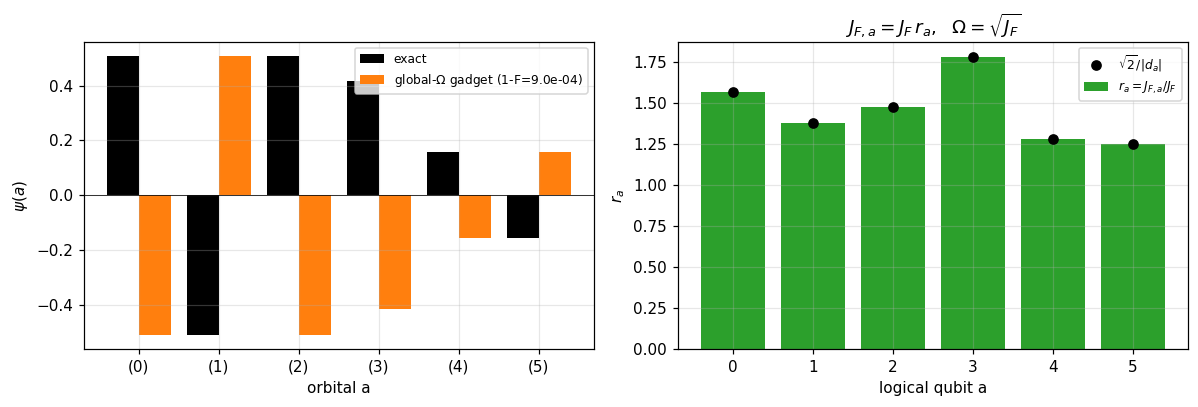

In [10]:
# Figure: psi(a) exact vs gadget, and the ratios r_a = J_F,a / J_F that realise d_a
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(D)
axes[0].bar(x - 0.2, psi_exact, 0.4, color="k", label="exact")
axes[0].bar(
    x + 0.2,
    res["amps"],
    0.4,
    color="C1",
    label=f"global-$\\Omega$ gadget (1-F={res['infidelity']:.1e})",
)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"({a})" for a in x])
axes[0].set_xlabel("orbital a")
axes[0].set_ylabel(r"$\psi(a)$")
axes[0].legend(fontsize=8)

axes[1].bar(x, res["r"], color="C2", label=r"$r_a=J_{F,a}/J_F$")
axes[1].plot(x, np.sqrt(2) / np.abs(d), "ko", label=r"$\sqrt{2}/|d_a|$")
axes[1].set_xticks(x)
axes[1].set_xlabel("logical qubit a")
axes[1].set_ylabel("$r_a$")
axes[1].set_title(r"$J_{F,a}=J_F\,r_a,\ \ \Omega=\sqrt{J_F}$")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Grid scan over $(\gamma,\ J_F/\gamma)$

- For every point: $J_F=(J_F/\gamma)\cdot\gamma$, $\Omega=\sqrt{J_F}$, $J_{F,a}=J_Fr_a$. Nothing else is tuned.
- Stored on the grid: $1-F$, $1-F$ in the code space, leakage, $|\Delta E|/|E|$, and the gap.
- About 3 s per point.

In [11]:
GAMMAS = np.logspace(0, np.log10(400), 20)  # 10 ... 400
JF_OVER_GAMMA = np.logspace(0, 5, 20)  # J_F / gamma = 10 ... 1e5

KEYS = ("infidelity", "infidelity_code", "leakage", "rel_energy_error", "gap")
grid = {m: np.full((len(GAMMAS), len(JF_OVER_GAMMA)), np.nan) for m in KEYS}
t0 = time.time()
for i, g in enumerate(GAMMAS):
    for j, x in enumerate(JF_OVER_GAMMA):
        try:
            r = run_point(g, x * g)
        except Exception as exc:  # e.g. exact r_a < 0 if J_F < t^2
            print(f"  gamma={g:.1f} J_F/gamma={x:.1e}: {exc}")
            continue
        for m in KEYS:
            grid[m][i, j] = r[m]
    print(
        f"gamma={g:6.1f}  1-F: " + "  ".join(f"{v:.1e}" for v in grid["infidelity"][i])
    )
unemb = np.array([run_unembedded(g) for g in GAMMAS])
print(f"done in {time.time() - t0:.0f}s")

np.savez(
    os.path.join(ROOT, "data", "O18_global_field_chain_tuning_grid.npz"),
    gammas=GAMMAS,
    jf_over_gamma=JF_OVER_GAMMA,
    d=d,
    chains=k_len,
    r_mode=R_MODE,
    unembedded_infidelity=unemb[:, 0],
    unembedded_rel_energy_error=unemb[:, 1],
    **grid,
)

gamma=   1.0  1-F: 1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00
gamma=   1.4  1-F: 1.0e+00  9.8e-01  9.7e-01  9.6e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01  9.5e-01
gamma=   1.9  1-F: 9.4e-01  8.8e-01  8.4e-01  8.2e-01  8.1e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01  8.0e-01
gamma=   2.6  1-F: 8.0e-01  6.9e-01  6.3e-01  5.9e-01  5.8e-01  5.7e-01  5.7e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01  5.6e-01
gamma=   3.5  1-F: 6.3e-01  5.0e-01  4.3e-01  3.9e-01  3.6e-01  3.5e-01  3.4e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01  3.3e-01
gamma=   4

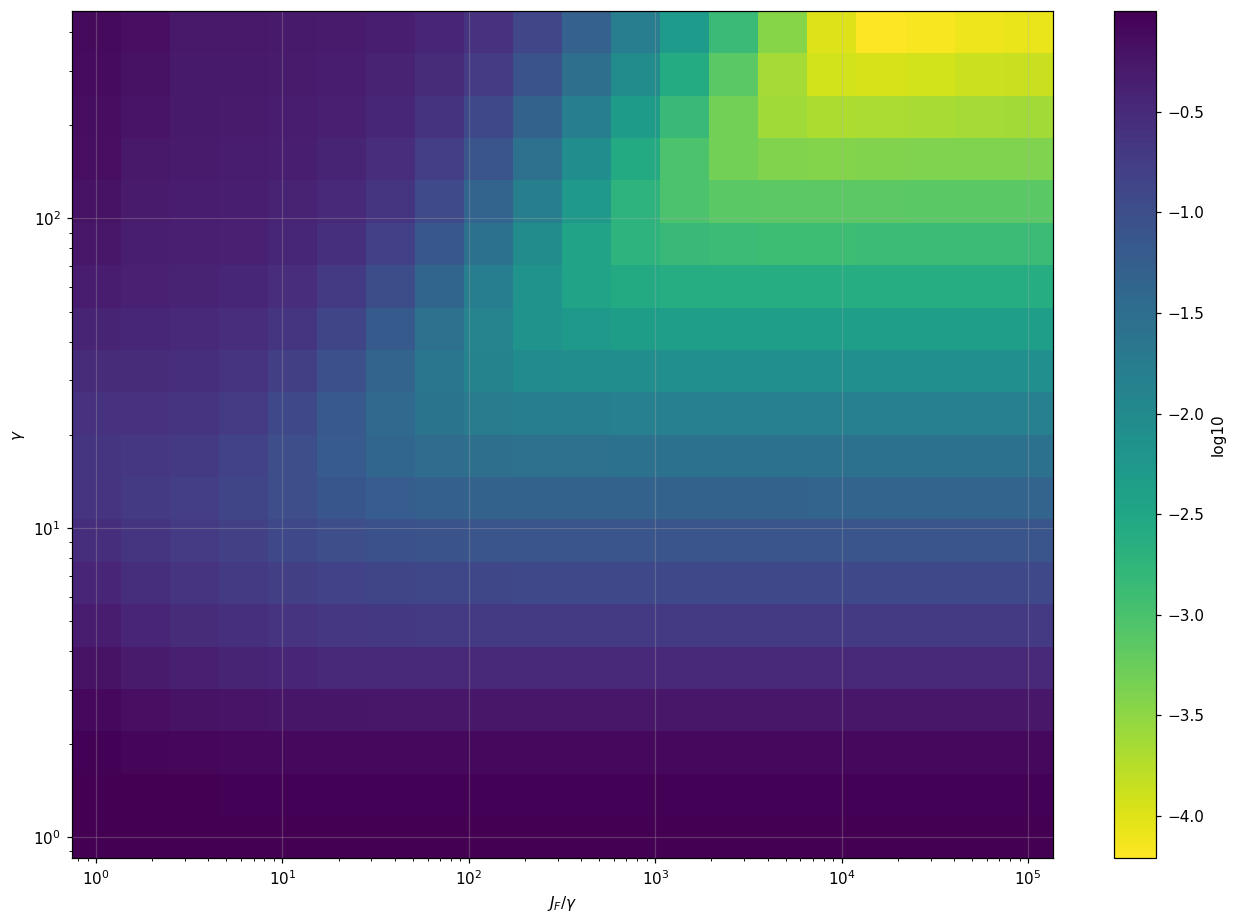

In [23]:
# Figure: the four figures of merit on the (J_F/gamma, gamma) grid
def log_edges(x):  # cell edges for a log-spaced grid
    lx = np.log10(x)
    mid = 0.5 * (lx[1:] + lx[:-1])
    return 10 ** np.r_[2 * lx[0] - mid[0], mid, 2 * lx[-1] - mid[-1]]


titles = {
    "infidelity": "1 - F",
}
fig, ax = plt.subplots(figsize=(12, 8.5))
Z = np.log10(np.clip(grid["infidelity"], 1e-12, None))
im = ax.pcolormesh(
    log_edges(JF_OVER_GAMMA), log_edges(GAMMAS), Z, shading="flat", cmap="viridis_r"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$J_F/\gamma$")
ax.set_ylabel(r"$\gamma$")
plt.colorbar(im, ax=ax, label="log10")
# guide: J_F = gamma^2 / t_max  (chains as soft as the constraint allows)
plt.tight_layout()
plt.show()

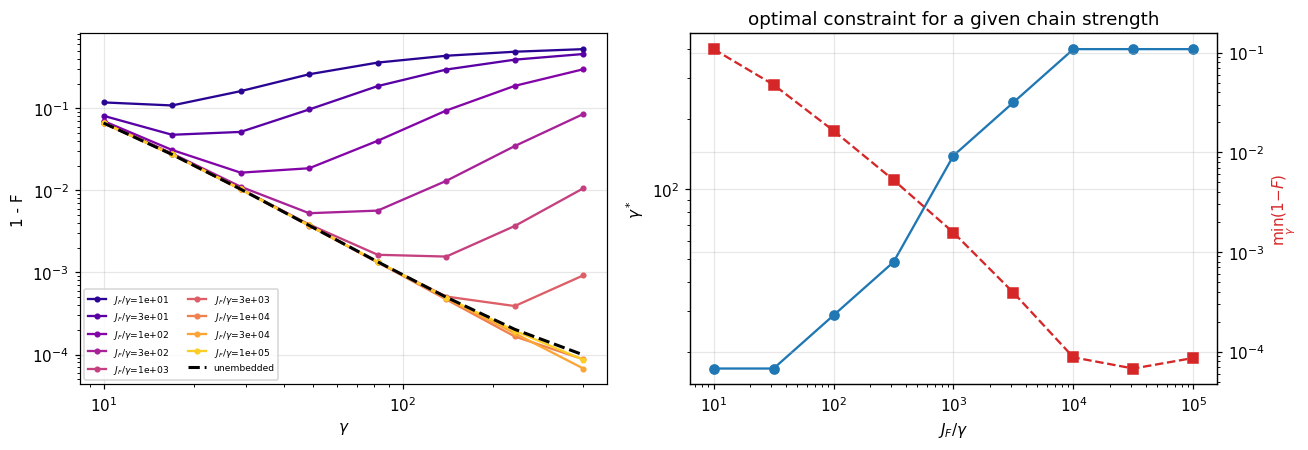

In [ ]:
# Figure: line cuts  1-F vs gamma at fixed J_F/gamma,  and the best gamma for each J_F/gamma
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cols = plt.get_cmap("plasma")(np.linspace(0.05, 0.9, len(JF_OVER_GAMMA)))
for j, x in enumerate(JF_OVER_GAMMA):
    axes[0].loglog(
        GAMMAS,
        grid["infidelity"][:, j],
        "o-",
        ms=3,
        color=cols[j],
        label=f"$J_F/\\gamma$={x:.0e}",
    )
axes[0].loglog(GAMMAS, unemb[:, 0], "k--", lw=2, label="unembedded")
axes[0].set_xlabel(r"$\gamma$")
axes[0].set_ylabel("1 - F")
axes[0].legend(fontsize=6, ncol=2)

best_i = np.nanargmin(grid["infidelity"], axis=0)
axes[1].loglog(JF_OVER_GAMMA, GAMMAS[best_i], "o-", label=r"best $\gamma$")
axes[1].set_xlabel(r"$J_F/\gamma$")
axes[1].set_ylabel(r"$\gamma^*$")
ax2 = axes[1].twinx()
ax2.loglog(JF_OVER_GAMMA, np.nanmin(grid["infidelity"], axis=0), "s--", color="C3")
ax2.set_ylabel(r"$\min_\gamma(1-F)$", color="C3")
axes[1].set_title("optimal constraint for a given chain strength")
plt.tight_layout()
plt.show()

**Reading the grid**
- **Top-left region** (small $J_F/\gamma$, large $\gamma$): $J_F<\gamma^2/t$. The chains are softer than the constraint and the embedding fails.
- **Bottom** (small $\gamma$): the gadget itself is bad, with leakage $\sim\gamma^{-2}$, however stiff the chains are.
- **The valley** follows $J_F\sim\gamma^2$, i.e. $J_F/\gamma\propto\gamma$. At fixed $J_F/\gamma$ the best $\gamma^*$ grows with $J_F/\gamma$ (right panel).
- **Numbers from this run:** the fidelity reaches the unembedded value once $J_F\gtrsim 30\,\gamma^2$, about 20× above the dashed line (at $\gamma=400$ that means $J_F/\gamma\gtrsim10^4$). For $J_F/\gamma\ge10^4$ the optimum $\gamma^*$ sits on the grid edge ($\gamma=400$): extend `GAMMAS` to find it.
- **Leakage depends almost only on $\gamma$.** The code-space infidelity carries the embedding error.
- If a single cell beats the unembedded value, check for the accidental cancellation with the $c_{ab}$ cap before reading anything into it.

In [ ]:
# pert vs exact r_a on a few grid points (gamma = 100)
g = 100.0
print(
    f"{'J_F/g':>8} {'1-F exact':>11} {'1-F pert':>11} {'dE/E exact':>11} {'dE/E pert':>11}"
)
for x in (1e1, 1e2, 1e3, 1e4):
    a, b = run_point(g, x * g, "exact"), run_point(g, x * g, "pert")
    print(
        f"{x:8.0e} {a['infidelity']:11.3e} {b['infidelity']:11.3e} "
        f"{a['rel_energy_error']:11.3e} {b['rel_energy_error']:11.3e}"
    )

   J_F/g   1-F exact    1-F pert  dE/E exact   dE/E pert


   1e+01   3.925e-01   3.925e-01   8.023e-01   8.020e-01


   1e+02   5.557e-02   5.557e-02   1.374e-01   1.374e-01


   1e+03   1.406e-03   1.406e-03   1.455e-02   1.456e-02


   1e+04   9.050e-04   9.050e-04   7.141e-05   7.086e-05


## 7. What the hardware has to provide

Everything is relative to the largest coefficient, the chain bond $J_F\max_a r_a$.

| quantity | value | relative to $J_F\max r$ |
|---|---|---|
| chain bonds $J_{F,a}$ | $J_F\,r_a$, spread $\max r/\min r=\max\lvert d\rvert/\min\lvert d\rvert$ | 1 |
| global field | $\Omega=\sqrt{J_F}$ | $1/\sqrt{J_F}$ |
| constraint couplers | $(2+c)\gamma$ | $\sim 2\gamma/J_F$ |
| logical splittings | $\sim d^2/\gamma$ | $\sim 1/(\gamma J_F)$ |

- **Only one non-uniform knob:** the ratios $r_a$, and they are $O(1)$ (about 1.25 to 1.78 for O18).
- On D-Wave, $\Omega/J$ is fixed by the anneal point, $A(s^*)/B(s^*)$. So $\Omega=\sqrt{J_F}$ means choosing $s^*$ such that $A/B=1/\sqrt{J_F}$ in units of the coupler scale.

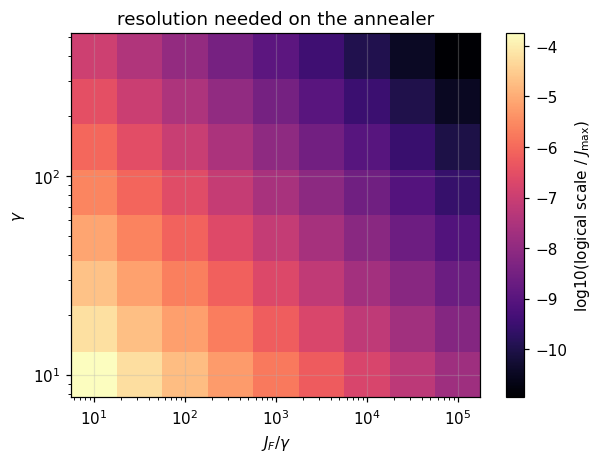

In [ ]:
# relative resolution: logical scale / largest coupler, on the same grid
res_grid = (t_target.min() ** 2 / GAMMAS[:, None]) / (
    JF_OVER_GAMMA[None, :] * GAMMAS[:, None] * ratios(1e6).max()
)
fig, ax = plt.subplots(figsize=(6, 4.3))
im = ax.pcolormesh(
    log_edges(JF_OVER_GAMMA),
    log_edges(GAMMAS),
    np.log10(res_grid),
    shading="flat",
    cmap="magma",
)
cs = ax.contour(JF_OVER_GAMMA, GAMMAS, np.log10(res_grid), levels=[-2], colors="c")
ax.clabel(cs, fmt={-2: r"$\delta J\sim10^{-2}$"}, fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$J_F/\gamma$")
ax.set_ylabel(r"$\gamma$")
plt.colorbar(im, ax=ax, label=r"log10(logical scale / $J_{\max}$)")
ax.set_title("resolution needed on the annealer")
plt.show()

## Summary

- **Parametrisation:** $J_{F,a}=J_F r_a$ with $\Omega^k=J_F^{k-1}$ ($\Omega=\sqrt{J_F}$ for $k=2$) gives $t_a=1/r_a^{k-1}$.
  - The drive is set only by the dimensionless ratios, $r_a=\sqrt2/|d_a|$. The scale $J_F$ drops out.
  - The signs of $d_a$ come for free through the gauge $\sigma_a$.
- **Every chain needs the same length $k\ge2$**, so that one global $\Omega$ serves all of them. That is 12 physical qubits for O18.
- **The grid $(\gamma,J_F/\gamma)$ has a valley along $J_F\sim\gamma^2$.** At fixed $J_F/\gamma$ there is an optimal $\gamma^*$: larger $\gamma$ reduces leakage but softens the chains relative to the constraint.
- **Next steps:**
  - run with `CAP=None` plus the constrained fit;
  - add ICE noise on $r_a$, since $\delta d_a/d_a=-\delta r_a/r_a$;
  - handle mixed chain lengths (these need $\Omega^k=J_F^{k-1}$ for each $k$, so equal $k$ or per-$k$ rescaling of $J_F$).